|<h2>Substack post:</h2>|<h1><a href="https://mikexcohen.substack.com/p/exploring-a-residual-vector-quantization" target="_blank">Exploring a residual vector quantization (RVQ) model</a></h1>|
|-|:-:|
|<h2>Teacher:<h2>|<h1>Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h1>|

<br>

<i>Using the code without reading the post may lead to confusion or errors.</i>

In [ ]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from IPython.display import Audio as ipAudio # different name b/c of datasets:Audio

from datasets import load_dataset, Audio
from transformers import EncodecModel, AutoProcessor

In [ ]:
### matplotlib adjustments (for dark mode)

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'figure.facecolor': '#191919',#'#282a2c',
    'figure.edgecolor': '#191919',
    'axes.facecolor':   '#191919',
    'axes.edgecolor':   '#DDE2F4',
    'axes.labelcolor':  '#DDE2F4',
    'xtick.color':      '#DDE2F4',
    'ytick.color':      '#DDE2F4',
    'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300
})

# **Demo of simple quantization**

In [ ]:
y = np.cumsum(np.random.randn(100))

qy = np.digitize(y,np.linspace(y.min(),y.max(),4))

fig,ax = plt.subplots(1,figsize=(8,3))
ax.plot(y,'w')

ax2 = ax.twinx()
ax2.plot(qy,'s',color=[.9,.3,.3])
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color([.9,.3,.3])

ax.set(xlabel='Time (a.u.)',ylabel='Waveform amplitude')
ax2.set(yticks=range(1,5),ylabel='Quantized bin')
plt.show()

# **Import model and process data**

In [ ]:
## key references
# https://arxiv.org/pdf/2210.13438
# https://huggingface.co/facebook/encodec_24khz

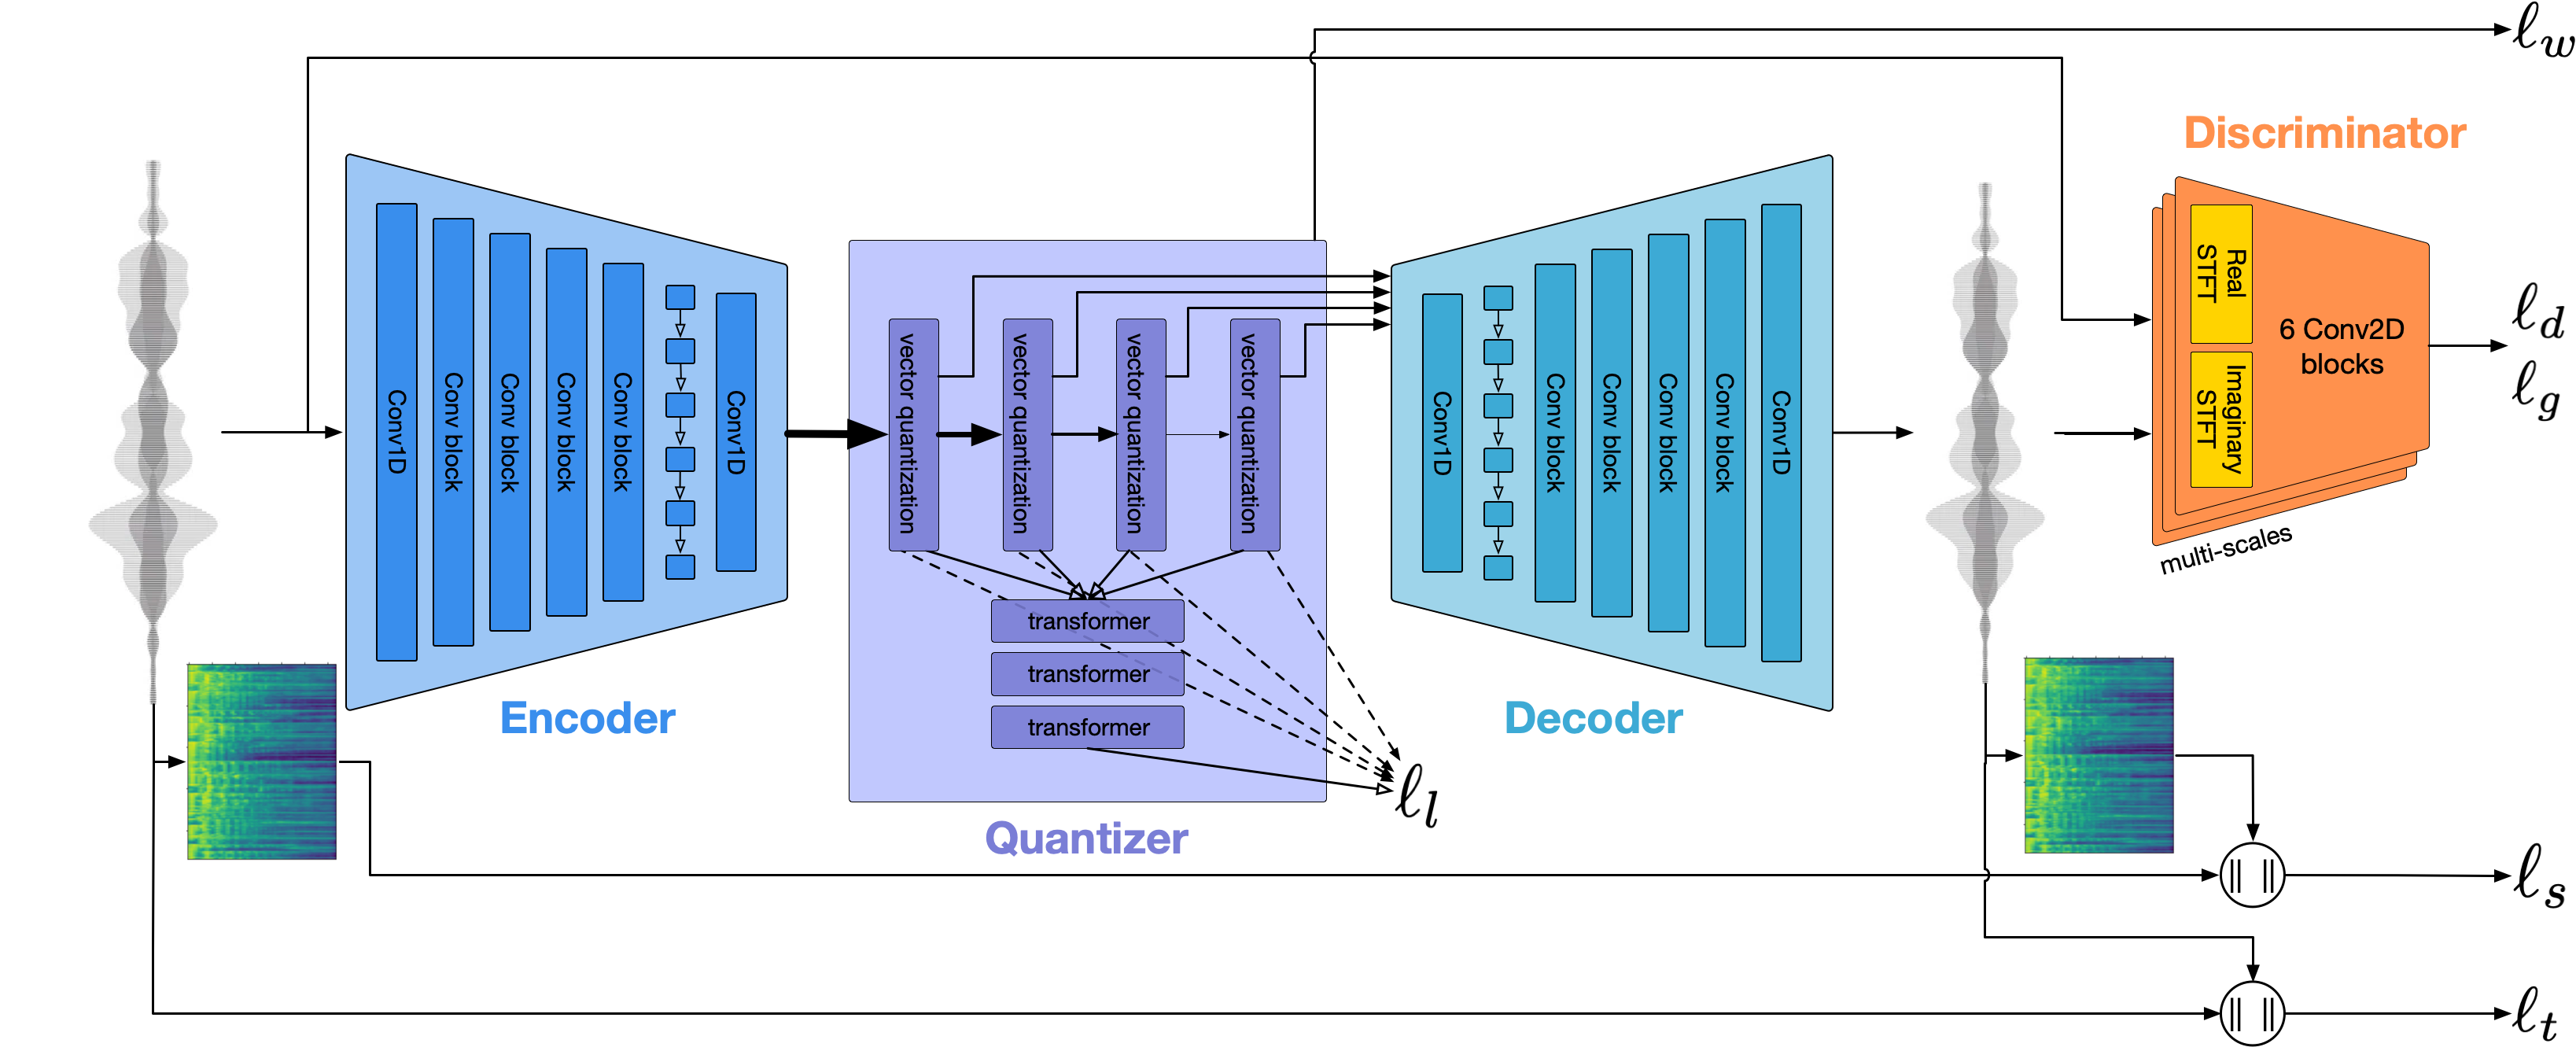

In [ ]:
# load the model + processor (for pre-processing the audio)
model = EncodecModel.from_pretrained('facebook/encodec_24khz')
processor = AutoProcessor.from_pretrained('facebook/encodec_24khz')
model.eval()

In [ ]:
# some model meta-data
model.config

In [ ]:
# load a demo dataset
a_dataset = load_dataset('hf-internal-testing/librispeech_asr_dummy','clean',split='validation')

# pick a sample index to use
whichsample = 2

# the model requires 24 kHz sampling rate
print(f'Original data has srate = {a_dataset[whichsample]["audio"]["sampling_rate"]}')
a_dataset = a_dataset.cast_column('audio', Audio(sampling_rate=processor.sampling_rate))
print(f'Now has srate = {a_dataset[whichsample]["audio"]["sampling_rate"]}')

# final processing for pytorch format
inputs = processor(raw_audio=a_dataset[whichsample]['audio']['array'], sampling_rate=processor.sampling_rate, return_tensors='pt')

In [ ]:
# encode then decode the audio inputs (option to change bandwidth -> N layers)
encoded = model.encode(inputs['input_values'], inputs['padding_mask'])#, bandwidth=12.)
decoded = model.decode(encoded.audio_codes, encoded.audio_scales, inputs['padding_mask'])

In [ ]:
# batch, chans, n_codebooks, n_frames
_,_,n_codebooks,n_frames = encoded.audio_codes.shape

max_possible_values = 1024 * n_codebooks

# find the total number of actual values
uniqsig = torch.zeros(n_frames)
for i in range(n_codebooks):
  uniqsig += i*1024 + encoded.audio_codes[0,0,i,:]

used_values = torch.unique(uniqsig)
print(f'There are {n_codebooks} codebooks and {n_frames} time points.')
print(f'There are {len(used_values)} unique states out of a max possible {max_possible_values}.')

In [ ]:
_,axs = plt.subplots(2,1,figsize=(12,5))

# define a time vector
srate = a_dataset[2]['audio']['sampling_rate']
timevec = np.arange(decoded['audio_values'].shape[-1]) / srate

# plot the signal
axs[0].plot(timevec,inputs['input_values'].squeeze(),'w',linewidth=.3)
axs[0].set(xlabel='Time (seconds)',ylabel='Signal amplitude',xlim=timevec[[0,-1]],
           title='Time series speech signal')

# plot its encoded representation
axs[1].plot(encoded.audio_codes[0,0,0,:],'bo',markersize=5,markerfacecolor=[.7,.7,.9,.5])
axs[1].plot(encoded.audio_codes[0,0,1,:],'rs',markersize=5,markerfacecolor=[.9,.7,.7,.5])
axs[1].legend(['Codebook 0','Codebook 1'],fontsize=8,loc=[.95,.1],facecolor='k')
axs[1].set(xlabel='Time (compressed indices)',ylabel='Codeword index',
           xlim=[-5,encoded.audio_codes.shape[-1]+4],title='Codeword sequences')

plt.tight_layout()
plt.show()

In [ ]:
# take the final codewords as the "silent" words for later in the code
quiet_L0,quiet_L1 = encoded.audio_codes[0,0,:,-1]

print(f'"Quiet codewords" for layers 0 and 1 are {quiet_L0} and {quiet_L1}')

In [ ]:
decoded['audio_values'].shape, inputs['input_values'].shape

In [ ]:
_,axs = plt.subplots(1,2,figsize=(12,5))

# plot the signals over time
axs[0].plot(timevec,decoded['audio_values'].squeeze().detach().numpy(),label='Reconstructed')
axs[0].plot(timevec,inputs['input_values'].squeeze(),label='Original')
axs[0].set(xlabel='Time (s)',xlim=timevec[[0,-1]],ylabel='Amplitude')
axs[0].legend()

# scatter plot
axs[1].plot(inputs['input_values'].squeeze()[::3],
            decoded['audio_values'].squeeze()[::3].detach().numpy(),'.',markerfacecolor=[.7,.7,.9,.5])
axs[1].axline((0,0),slope=1,color='w')
axs[1].set(xlabel='Original signal',ylabel='Decoded from codebooks')

plt.tight_layout()
plt.show()

In [ ]:
# the input
print('Original input signal')
display(ipAudio(inputs["input_values"].squeeze(),rate=srate))

# the decoded
print('\n\nDecoded signal')
display(ipAudio(decoded[0].squeeze().detach(),rate=srate))

In [ ]:
decoded[0].shape

In [ ]:
print(f'Original sound file has {decoded.audio_values.numel():7,} numbers')
print(f' Encoded sound file has {encoded.audio_codes.numel():7,} numbers\n')
print(f'Encoded is {encoded.audio_codes.numel()/decoded.audio_values.numel():.2%} the number of elements as the original!')

# **Encoder shapes and weights**

In [ ]:
model.encoder.layers[13]

In [ ]:
for W in model.encoder.layers.named_parameters():
  if 'weight' in W[0]:
    print(f'{W[0]:>50}: {list(W[1].shape)}')

In [ ]:
# an aside on the exponential linear unit

# create two ELU objects
elu1 = nn.ELU(alpha=.5)
elu2 = nn.ELU(alpha=1)

# input values
x = torch.linspace(-3,2,101)

# plot
plt.figure(figsize=(8,4))
plt.plot(x,F.relu(x),linewidth=2,label='ReLU')
plt.plot(x,elu1(x),linewidth=2,label=f'ELU ($\\alpha$ = {elu1.alpha})')
plt.plot(x,elu2(x),linewidth=2,label=f'ELU ($\\alpha$ = {elu2.alpha})')

plt.legend()
plt.gca().set(xlabel='Input',ylabel='Output',xlim=x[[0,-1]])
plt.show()

# **Quantizer shapes and weights**

In [ ]:
for i in range(len(model.quantizer.layers)):
  print(f'Quantizer layer {i:2} has size {list(model.quantizer.layers[i].codebook.embed.shape)}')

In [ ]:
_,axs = plt.subplots(2,2,figsize=(12,6))

axs[0,0].imshow(model.quantizer.layers[0].codebook.embed.T,cmap='plasma',aspect='auto',vmin=-5,vmax=5)
axs[0,0].set(xlabel='Codeword (token) indices',ylabel='Embeddings dimension',title='A) Codebook 0')
axs[0,1].imshow(model.quantizer.layers[1].codebook.embed.T,cmap='plasma',aspect='auto',vmin=-.5,vmax=.5)
axs[0,1].set(xlabel='Codeword (token) indices',ylabel='Embeddings dimension',title='B) Codebook 1')

axs[1,0].plot(model.quantizer.layers[0].codebook.embed[np.arange(0,1023,step=200),:].T)
axs[1,0].set(xlabel='Embeddings (latent) dimension',ylabel='Embeddings value',title='C) Selection of vectors from codebook 0')
axs[1,1].plot(model.quantizer.layers[1].codebook.embed[np.arange(0,1023,step=200),:].T)
axs[1,1].set(xlabel='Embeddings (latent) dimension',ylabel='Embeddings value',title='D) Selection of vectors from codebook 1')

plt.tight_layout()
plt.show()

In [ ]:
## cosine similarities

# extract and normalize the vectors from the first two codebooks
q0 = model.quantizer.layers[0].codebook.embed.clone()
q1 = model.quantizer.layers[1].codebook.embed.clone()
q0 /= torch.norm(q0,dim=1,keepdim=True)
q1 /= torch.norm(q1,dim=1,keepdim=True)

# calculate cosine similarities
Cs_00 = q0 @ q0.T
Cs_11 = q1 @ q1.T
Cs_01 = q0 @ q1.T

# extract the nonredundant elements
Cs_00_u = Cs_00[np.triu_indices(Cs_00.shape[0],k=1)]
Cs_11_u = Cs_11[np.triu_indices(Cs_11.shape[0],k=1)]



# within codebook-0
fig,axs = plt.subplots(2,3,figsize=(11,6))
h = axs[0,0].imshow(Cs_00,cmap='plasma',aspect='auto')
axs[0,0].set(xticks=[],yticks=[],xlabel='Codewords from book 0',ylabel='Codewords from book 0',title='Similarities of codebook 0')
fig.colorbar(h,ax=axs[0,0],pad=.01,fraction=.045)

axs[1,0].hist(Cs_00_u,bins='fd')
axs[1,0].axvline(torch.nanmean(Cs_00_u),color='r',label=f'$\\overline{{S_c}}$={torch.nanmean(Cs_00_u):.3f}')
axs[1,0].set(xlabel='Cosine similarity value',yticks=[],ylabel='Count',title='Distribution of similarity values',xlim=[-1,1])
axs[1,0].legend()



# within codebook-1
h = axs[0,1].imshow(Cs_11,cmap='plasma',vmin=-.3,vmax=.3,aspect='auto')
axs[0,1].set(xticks=[],yticks=[],xlabel='Codewords from book 1',ylabel='Codewords from book 1',title='Similarities of codebook 1')
fig.colorbar(h,ax=axs[0,1],pad=.01,fraction=.045)

axs[1,1].hist(Cs_11_u,bins='fd')
axs[1,1].axvline(torch.nanmean(Cs_11_u),color='r',label=f'$\\overline{{S_c}}$={torch.nanmean(Cs_11_u):.3f}')
axs[1,1].set(xlabel='Cosine similarity value',yticks=[],ylabel='Count',title='Distribution of similarity values',xlim=[-1,1])
axs[1,1].legend()



# between codebooks
h = axs[0,2].imshow(Cs_01,cmap='plasma',vmin=-.3,vmax=.3,aspect='auto')
axs[0,2].set(xticks=[],yticks=[],xlabel='Codewords from book 0',ylabel='Codewords from book 1',title='Books 0-1 similarities')
fig.colorbar(h,ax=axs[0,2],pad=.01,fraction=.045)

axs[1,2].hist(Cs_01.flatten(),bins='fd')
axs[1,2].axvline(torch.nanmean(Cs_01),color='r',label=f'$\\overline{{S_c}}$={torch.nanmean(Cs_01):.3f}')
axs[1,2].set(xlabel='Cosine similarity value',yticks=[],ylabel='Count',title='Distribution of similarity values',xlim=[-1,1])
axs[1,2].legend()


plt.tight_layout()
plt.show()

In [ ]:
# e.g., dead codeword:
model.quantizer.layers[0].codebook.embed[116]

In [ ]:
# approximate counting of dead codewords by small norms
num_dead = torch.where(torch.norm(model.quantizer.layers[0].codebook.embed,dim=1)<.01)[0].numel()

plt.figure(figsize=(8,4))
plt.plot(torch.norm(model.quantizer.layers[0].codebook.embed,dim=1),'wh',markerfacecolor=[.9,.7,.7,.5])
plt.gca().set(ylabel='Vector norm',xlabel='Codeword index',
              title=f'{num_dead} "dead" codewords (norm<.01)')

plt.show()

# **What do the latent vectors sound like?**

In [ ]:
# pick two vectors
codeword_L0 = 42
codeword_L1 = 84

# create the encoding matrix with zeros
encd = torch.full((1,1,2,200),0,dtype=torch.long)

# replace with the "quiet" codewords discovered earlier
encd[0,0,0,:] = quiet_L0
encd[0,0,1,:] = quiet_L1

# then replace specific time points
encd[0,0,0,[ 50,150]] = codeword_L0
encd[0,0,1,[100,150]] = codeword_L1

# decode to waveform
waveform = model.decode(encd,[None])

# print the shapes
print(f'Encoding size: {list(encd.shape)}')
print(f'Waveform size: {list(waveform.audio_values.shape)}')

# play it
ipAudio(waveform.audio_values.detach().squeeze(),rate=srate)

In [ ]:
_,axs = plt.subplots(1,3,figsize=(12,3.5))

# get the vectors
vec_L0 = model.quantizer.layers[0].codebook.embed[codeword_L0,:]
vec_L1 = model.quantizer.layers[1].codebook.embed[codeword_L1,:]

# plot the vectors
axs[0].plot(vec_L0,'ws',markerfacecolor=[.9,.1,.7],markersize=4,label=f'Vector L0c{codeword_L0}')
axs[0].plot(vec_L1,'wo',markerfacecolor=[.1,.5,.7],markersize=4,label=f'Vector L1c{codeword_L1}')
axs[0].set(xlabel='Vector dimension',ylabel='Latent space amplitude',title='A) Two latent vectors')
axs[0].legend(fontsize=7)


axs[1].plot(encd[0,0,0,:],'ws',markerfacecolor=[.9,.1,.7],label=f'Vector L0c{codeword_L0}')
axs[1].plot(encd[0,0,1,:],'wo',markerfacecolor=[.1,.5,.7],label=f'Vector L1c{codeword_L1}')
axs[1].legend(fontsize=7,loc=[.6,.5])
axs[1].set(xlabel='Time (downsampled indices)',ylabel='Codeword index',title='B) Encoding')

waveform_np = waveform.audio_values.squeeze().detach().numpy()
axs[2].plot(np.arange(len(waveform_np))/srate,waveform_np,'w',linewidth=.5)
axs[2].set(xlabel='Time (seconds)',ylabel='Signal amplitude',title='C) Decoded')

plt.tight_layout()
plt.show()

# **Decoding with only one codebook**

In [ ]:
# pick a sample index to use
whichsample = 20

# process and encode the signal
a_dataset = a_dataset.cast_column('audio', Audio(sampling_rate=processor.sampling_rate))
inputs = processor(raw_audio=a_dataset[whichsample]['audio']['array'], sampling_rate=processor.sampling_rate, return_tensors='pt')

# encode then decode the audio inputs
encoded = model.encode(inputs['input_values'], inputs['padding_mask'])

In [ ]:
# make copies to manipulate
encoded_L0 = encoded.copy()
encoded_L1 = encoded.copy()

encoded_L0.audio_codes = encoded.audio_codes.clone() # .copy() doesn't extend into elements of containers
encoded_L1.audio_codes = encoded.audio_codes.clone()


# silence the other layer
encoded_L0.audio_codes[0,0,1,:] = quiet_L1
encoded_L1.audio_codes[0,0,0,:] = quiet_L0

# small tangent: you can reconstruct only the first codebook by removing the second, but cannot remove the first and keep the second
#npts = encoded_L0.audio_codes.shape[-1]
#encoded_L0.audio_codes = encoded_L0.audio_codes[0,0,0,:].reshape(1,1,1,npts) # <- this works
#encoded_L1.audio_codes = encoded_L1.audio_codes[0,0,1,:].reshape(1,1,1,npts) # <- this doesn't work (codewords-1 indices are applied to codebook-0)

# reconstruct the two versions
decoded    = model.decode(encoded.audio_codes, encoded.audio_scales, inputs['padding_mask'])
decoded_L0 = model.decode(encoded_L0.audio_codes, encoded_L0.audio_scales, inputs['padding_mask'])
decoded_L1 = model.decode(encoded_L1.audio_codes, encoded_L1.audio_scales, inputs['padding_mask'])

In [ ]:
# coding side note: show that container elements are not copied
test = encoded.copy()
id(encoded.audio_codes), id(encoded_L1.audio_codes), id(test.audio_codes)

In [ ]:
print('Original signal')
display(ipAudio(inputs['input_values'].squeeze(),rate=srate))

print('\n\nReconstruction with two codebooks')
display(ipAudio(decoded.audio_values.squeeze().detach(),rate=srate))

print('\n\nReconstruction with FIRST codebook')
display(ipAudio(decoded_L0.audio_values.squeeze().detach(),rate=srate))

print('\n\nReconstruction with SECOND codebook')
display(ipAudio(decoded_L1.audio_values.squeeze().detach(),rate=srate))

In [ ]:
plt.figure(figsize=(12,4))

# redefine the time vector
srate = a_dataset[2]['audio']['sampling_rate']
timevec = np.arange(decoded['audio_values'].shape[-1]) / srate

plt.plot(timevec,inputs['input_values'].squeeze(),linewidth=.4,label='Original')
plt.plot(timevec,decoded_L0['audio_values'].squeeze().detach().numpy(),linewidth=.4,label='C0 only')
plt.plot(timevec,decoded_L1['audio_values'].squeeze().detach().numpy(),label='C1 only')

plt.gca().set(xlabel='Time (s)',xlim=timevec[[0,-1]],ylabel='Amplitude')
plt.legend()
plt.show()

In [ ]:
# calculate the various correlation coefficients
r_id = np.corrcoef(inputs['input_values'].squeeze().detach().numpy(),
                   decoded['audio_values'].squeeze().detach().numpy() )

r_i0 = np.corrcoef(inputs['input_values'].squeeze().detach().numpy(),
                   decoded_L0['audio_values'].squeeze().detach().numpy() )

r_i1 = np.corrcoef(inputs['input_values'].squeeze().detach().numpy(),
                   decoded_L1['audio_values'].squeeze().detach().numpy() )

r_01 = np.corrcoef(decoded_L0['audio_values'].squeeze().detach().numpy(),
                   decoded_L1['audio_values'].squeeze().detach().numpy() )

# and plot
plt.figure(figsize=(10,4))
for i,r in enumerate([r_id[0,1],r_i0[0,1],r_i1[0,1],r_01[0,1]]):
  plt.bar(i,r,edgecolor='w',color=plt.cm.Reds(r))
  plt.text(i,r+.02,f'{r:.3f}',ha='center',fontweight='bold')

plt.gca().set(xticks=range(4),ylabel='Correlation coefficient',title='Correlations of partial decodings',
              xticklabels=['Input and full','Input and C0','Input and C1','C0 and C1'])
plt.show()

# **Decoder layer shapes**

In [ ]:
model.decoder

In [ ]:
# implant hooks into all decoder layers

# initialize empty dictionary
activations = {}

# attention hooks
def implant_hook(layer_number):
  def hook(module,input,output):
    activations[f'dec{layer_number}'] = output.detach()
    # activations[f'dec{layer_number}_n'] = module
  return hook


# surgeries
handles = []
for i in range(len(model.decoder.layers)):
  h = model.decoder.layers[i].register_forward_hook(implant_hook(i))
  handles.append(h)

In [ ]:
# run the model to activate the hooks
encoded = model.encode(inputs['input_values'], inputs['padding_mask'])
decoded = model.decode(encoded.audio_codes, encoded.audio_scales, inputs['padding_mask'])

# remove the hooks
for h in handles: h.remove()

In [ ]:
for k,v in activations.items():
  print(f'{k:5} has shape {list(v.shape)}')

In [ ]:
plt.figure(figsize=(12,5.5))
r = 0

for k,v in activations.items():

  # extract L1 mean
  l1mean = abs(v).mean(axis=1).squeeze().numpy()
  l1mean = (l1mean-l1mean.min()) / (l1mean.max()-l1mean.min())

  # create a time vector
  tvec = np.linspace(0,inputs['input_values'].numel()/srate,len(l1mean))
  plt.plot(tvec,l1mean-r,linewidth=.8,
           color=plt.cm.spring(r/len(activations.keys())),label=f'{k}')
  r += 1

plt.legend(fontsize=12,loc=(1,0),facecolor='k')
plt.gca().set(xlabel='Time (sec.)',yticks=[],ylabel='L1 mean (norm)',xlim=tvec[[0,-1]])

plt.tight_layout()
plt.show()